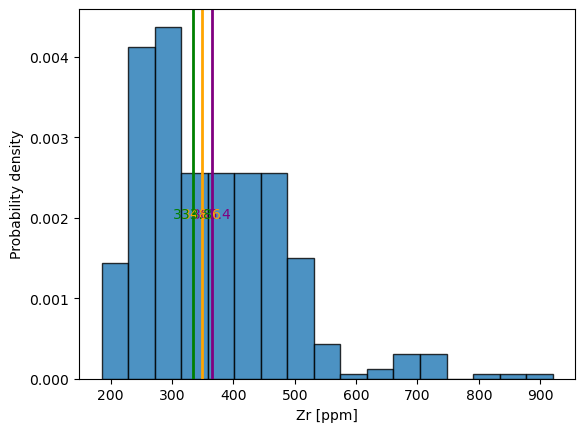

In [32]:
import pandas as pd
from scipy.stats.mstats import gmean, hmean
import matplotlib.pyplot as plt

my_dataset = pd.read_excel('Smith_glass_post_NYT_data.xlsx', sheet_name='Supp_traces')

a_mean = my_dataset.Zr.mean()
g_mean = gmean(my_dataset['Zr'])
h_mean = hmean(my_dataset['Zr'])

fig, ax = plt.subplots()

ax.hist(my_dataset.Zr, bins='auto', density=True, edgecolor='k', alpha=0.8)

# garis mean + label angka
ax.axvline(a_mean, color='purple', linewidth=2)
ax.text(a_mean, 0.002, f'{a_mean:.1f}', color='purple', ha='center')

ax.axvline(g_mean, color='orange', linewidth=2)
ax.text(g_mean, 0.002, f'{g_mean:.1f}', color='orange', ha='center')

ax.axvline(h_mean, color='green', linewidth=2)
ax.text(h_mean, 0.002, f'{h_mean:.1f}', color='green', ha='center')

ax.set_xlabel('Zr [ppm]')
ax.set_ylabel('Probability density')

plt.show()

-------
median
339.4 [ppm]
-------


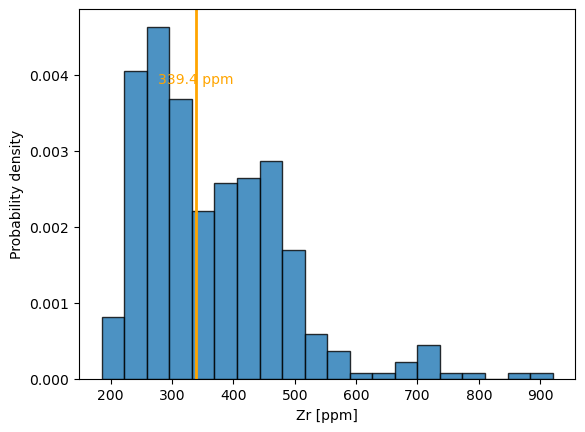

In [33]:
import pandas as pd  # library untuk membaca dan mengolah data (DataFrame)
import matplotlib.pyplot as plt  # library untuk membuat grafik

my_dataset = pd.read_excel('Smith_glass_post_NYT_data.xlsx', sheet_name='Supp_traces')  
# membaca file Excel dan mengambil data dari sheet 'Supp_traces'

median = my_dataset.Zr.median()  
# menghitung nilai median (nilai tengah)

print('-------')
print('median')
print("{0:.1f} [ppm]".format(median))
print('-------')

fig, ax = plt.subplots()  
# membuat area gambar

ax.hist(my_dataset.Zr, bins=20, density=True, edgecolor='k', alpha=0.8)  
# membuat histogram

ax.axvline(median, color='orange', linewidth=2)  
# garis median

# 🔥 tambahan: tampilkan angka median di grafik
ax.text(median, ax.get_ylim()[1]*0.8, f'{median:.1f} ppm', 
        color='orange', ha='center')
# ax.get_ylim()[1]*0.8 → posisi teks di 80% tinggi grafik

ax.set_xlabel('Zr [ppm]')
ax.set_ylabel('Probability density')

plt.show()

modal value: 277 [ppm]


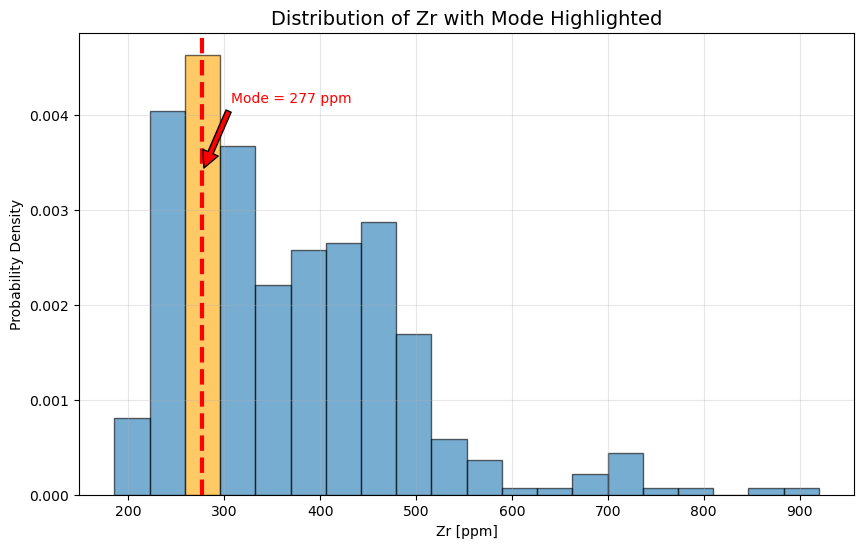

In [35]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

my_dataset = pd.read_excel('Smith_glass_post_NYT_data.xlsx', sheet_name='Supp_traces')

# hitung modus
hist, bin_edges = np.histogram(my_dataset['Zr'], bins=20, density=True)
modal_value = (bin_edges[hist.argmax()] + bin_edges[hist.argmax()+1]) / 2

print('modal value: {0:.0f} [ppm]'.format(modal_value))

fig, ax = plt.subplots(figsize=(10,6))  # 🔥 ukuran diperbesar

# histogram utama
n, bins, patches = ax.hist(my_dataset.Zr, bins=20, density=True, edgecolor='black', alpha=0.6)

# 🔥 highlight bin yang mengandung modus
max_bin_index = hist.argmax()
for i, patch in enumerate(patches):
    if i == max_bin_index:
        patch.set_facecolor('orange')  # bin modus jadi beda warna

# garis modus
ax.axvline(modal_value, color="red", linewidth=3, linestyle='--')

# 🔥 anotasi lengkap (bukan cuma angka)
ax.annotate(f'Mode = {modal_value:.0f} ppm',
            xy=(modal_value, ax.get_ylim()[1]*0.7),
            xytext=(modal_value+30, ax.get_ylim()[1]*0.85),
            arrowprops=dict(facecolor='red', shrink=0.05),
            fontsize=10,
            color='red')

# styling tambahan
ax.set_title('Distribution of Zr with Mode Highlighted', fontsize=14)
ax.set_xlabel('Zr [ppm]')
ax.set_ylabel('Probability Density')

ax.grid(alpha=0.3)  # 🔥 tambah grid biar lebih jelas

plt.show()

-------
Range
735
-------


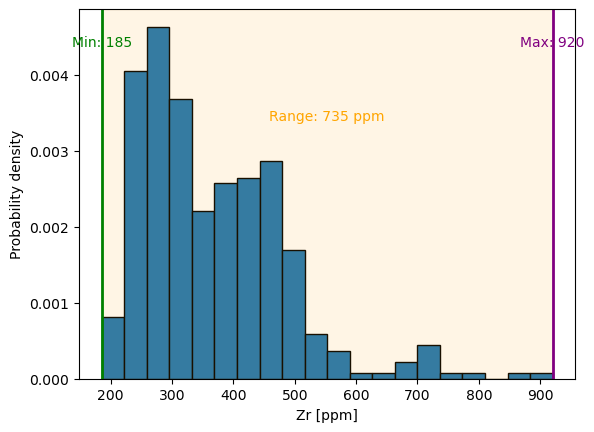

In [36]:
import pandas as pd
import matplotlib.pyplot as plt

my_dataset = pd.read_excel('Smith_glass_post_NYT_data.xlsx', sheet_name='Supp_traces')

my_range = my_dataset['Zr'].max() - my_dataset['Zr'].min()

min_val = my_dataset['Zr'].min()  # nilai minimum
max_val = my_dataset['Zr'].max()  # nilai maksimum

print('-------')
print('Range')
print("{0:.0f}".format(my_range))
print('-------')

fig, ax = plt.subplots()

ax.hist(my_dataset.Zr, bins=20, density=True, edgecolor='k')

# garis min & max
ax.axvline(max_val, color='purple', linewidth=2)
ax.axvline(min_val, color='green', linewidth=2)

# area range
ax.axvspan(min_val, max_val, alpha=0.1, color='orange')

# 🔥 tambahan: tampilkan angka di grafik
ax.text(min_val, ax.get_ylim()[1]*0.9, f'Min: {min_val:.0f}', 
        color='green', ha='center')

ax.text(max_val, ax.get_ylim()[1]*0.9, f'Max: {max_val:.0f}', 
        color='purple', ha='center')

# 🔥 label range di tengah
mid = (min_val + max_val) / 2
ax.text(mid, ax.get_ylim()[1]*0.7, f'Range: {my_range:.0f} ppm',
        color='orange', ha='center')

ax.set_xlabel('Zr [ppm]')
ax.set_ylabel('Probability density')

plt.show()


-------
Variance
14021 [square ppm]
-------
Standard Deviation
118 [ppm]
-------


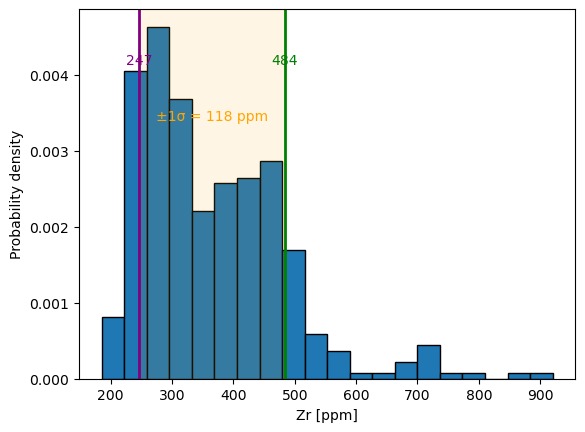

In [37]:
import pandas as pd
import matplotlib.pyplot as plt

my_dataset = pd.read_excel('Smith_glass_post_NYT_data.xlsx', sheet_name='Supp_traces')

variance = my_dataset['Zr'].var()
stddev = my_dataset['Zr'].std()
mean = my_dataset['Zr'].mean()  # 🔥 simpan mean biar dipakai berulang

print('-------')
print('Variance')
print("{0:.0f} [square ppm]".format(variance))
print('-------')
print('Standard Deviation')
print("{0:.0f} [ppm]".format(stddev))
print('-------')

fig, ax = plt.subplots()

ax.hist(my_dataset.Zr, bins=20, density=True, edgecolor='k')

# garis mean ± std
ax.axvline(mean - stddev, color='purple', linewidth=2)
ax.axvline(mean + stddev, color='green', linewidth=2)

# area range std
ax.axvspan(mean - stddev, mean + stddev, alpha=0.1, color='orange')

# 🔥 tambahan: tampilkan angka di grafik
ax.text(mean - stddev, ax.get_ylim()[1]*0.85, 
        f'{(mean - stddev):.0f}', color='purple', ha='center')

ax.text(mean + stddev, ax.get_ylim()[1]*0.85, 
        f'{(mean + stddev):.0f}', color='green', ha='center')

# 🔥 label tengah
ax.text(mean, ax.get_ylim()[1]*0.7, 
        f'±1σ = {stddev:.0f} ppm', color='orange', ha='center')

ax.set_xlabel('Zr [ppm]')
ax.set_ylabel('Probability density')

plt.show()

-------
Interquaritle range (IQR): 164 [ppm]
-------


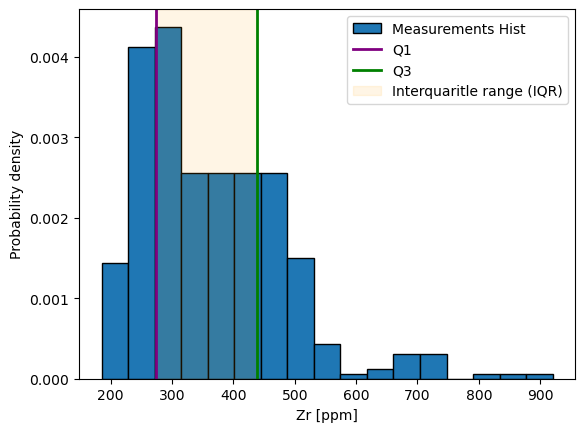

In [24]:
import pandas as pd  # library untuk membaca dan mengolah data
import numpy as np  # library untuk perhitungan numerik (percentile)
import matplotlib.pyplot as plt  # library untuk membuat grafik

my_dataset = pd.read_excel('Smith_glass_post_NYT_data.xlsx', sheet_name='Supp_traces')  
# membaca file Excel dan mengambil data dari sheet 'Supp_traces'

q1 = np.percentile(my_dataset.Zr, 25, method='midpoint')  
# menghitung kuartil pertama (Q1 = 25% data terbawah)

q3 = np.percentile(my_dataset.Zr, 75, method='midpoint')  
# menghitung kuartil ketiga (Q3 = 75% data terbawah)

iqr = q3 - q1  
# menghitung Interquartile Range (IQR):
# IQR = Q3 - Q1 → ukuran sebaran data bagian tengah (50% data)

print('-------')  # garis pemisah output

print('Interquaritle range (IQR): {0:.0f} [ppm]'.format(iqr))  
# menampilkan nilai IQR tanpa desimal

print('-------')  # garis pemisah output

fig, ax = plt.subplots()  
# membuat area gambar (figure) dan sumbu (axis)

ax.hist(my_dataset.Zr, bins='auto', density=True, edgecolor='k', label='Measurements Hist')  
# membuat histogram:
# bins='auto' → jumlah interval otomatis
# density=True → distribusi probabilitas
# edgecolor='k' → garis tepi hitam

ax.axvline(q1, color='purple', label='Q1', linewidth=2)  
# garis vertikal untuk kuartil pertama (Q1)

ax.axvline(q3, color='green', label='Q3', linewidth=2)  
# garis vertikal untuk kuartil ketiga (Q3)

ax.axvspan(q1, q3, alpha=0.1, color='orange', label='Interquaritle range (IQR)')  
# area bayangan antara Q1 dan Q3
# menunjukkan 50% data tengah (tanpa outlier)

ax.set_xlabel('Zr [ppm]')  
# memberi label sumbu X

ax.set_ylabel('Probability density')  
# memberi label sumbu Y

ax.legend()  
# menampilkan legenda

plt.show()  
# menampilkan grafik

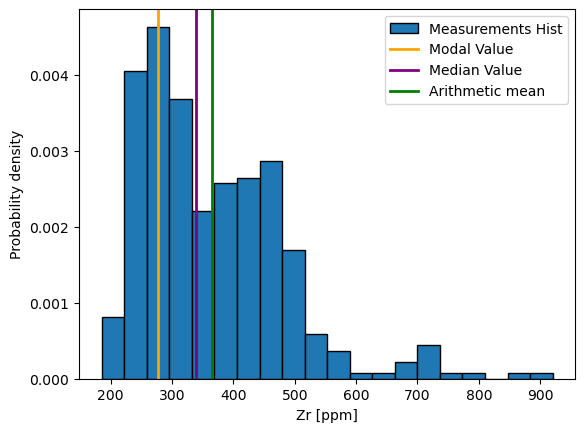

In [26]:
import pandas as pd  # library untuk membaca dan mengolah data
import numpy as np  # library untuk perhitungan numerik (histogram & modus)
import matplotlib.pyplot as plt  # library untuk membuat grafik

my_dataset = pd.read_excel('Smith_glass_post_NYT_data.xlsx', sheet_name='Supp_traces')  
# membaca file Excel dan mengambil data dari sheet 'Supp_traces'

a_mean = my_dataset.Zr.mean()  
# menghitung arithmetic mean (rata-rata biasa)

median = my_dataset.Zr.median()  
# menghitung median (nilai tengah data)

hist, bin_edges = np.histogram(my_dataset['Zr'], bins=20, density=True)  
# membuat histogram secara numerik:
# hist → frekuensi tiap bin
# bin_edges → batas interval

modal_value = (bin_edges[hist.argmax()] + bin_edges[hist.argmax()+1]) / 2  
# menghitung modus (nilai yang paling sering muncul):
# ambil bin dengan frekuensi tertinggi lalu cari titik tengahnya

fig, ax = plt.subplots()  
# membuat area gambar (figure) dan sumbu (axis)

ax.hist(my_dataset.Zr, bins=20, density=True, edgecolor='k', label="Measurements Hist")  
# membuat histogram:
# bins=20 → jumlah interval
# density=True → distribusi probabilitas
# edgecolor='k' → garis tepi hitam

ax.axvline(modal_value, color='orange', label='Modal Value', linewidth=2)  
# garis vertikal untuk modus (nilai paling sering muncul)

ax.axvline(median, color='purple', label='Median Value', linewidth=2)  
# garis vertikal untuk median (nilai tengah)

ax.axvline(a_mean, color='green', label='Arithmetic mean', linewidth=2)  
# garis vertikal untuk mean (rata-rata)

ax.set_xlabel('Zr [ppm]')  
# memberi label sumbu X

ax.set_ylabel('Probability density')  
# memberi label sumbu Y

ax.legend()  
# menampilkan legenda

plt.show()  
# menampilkan grafik

In [27]:
import numpy as np  # library untuk perhitungan numerik
from scipy.stats import skew  # fungsi untuk menghitung skewness (kemencengan distribusi)

a_mean = my_dataset.Zr.mean()  
# menghitung arithmetic mean (rata-rata)

median = my_dataset.Zr.median()  
# menghitung median (nilai tengah)

hist, bin_edges = np.histogram(my_dataset['Zr'], bins=20, density=True)  
# membuat histogram numerik:
# hist → frekuensi tiap bin
# bin_edges → batas interval

modal_value = (bin_edges[hist.argmax()] + bin_edges[hist.argmax()+1]) / 2  
# menghitung modus:
# ambil bin dengan frekuensi tertinggi lalu cari titik tengahnya

standard_deviation = my_dataset['Zr'].std()  
# menghitung standar deviasi (ukuran sebaran data)

a1 = (a_mean - modal_value) / standard_deviation  
# Pearson's first coefficient of skewness:
# membandingkan mean dengan modus

a2 = 3 * (a_mean - median) / standard_deviation  
# Pearson's second coefficient of skewness:
# membandingkan mean dengan median (dikalikan 3)

g1 = skew(my_dataset['Zr'])  
# Fisher-Pearson coefficient:
# menghitung skewness langsung dari distribusi data

print('-------')  # garis pemisah output

print("Pearson's first coefficient of skewness: {:.2f}".format(a1))  
# menampilkan hasil skewness metode Pearson pertama

print("Pearson's 2nd moment of skewness: {:.2f}".format(a2))  
# menampilkan hasil skewness metode Pearson kedua

print("Fisher-Pearson's coefficient of skewness: {:.2f}".format(g1))  
# menampilkan hasil skewness metode Fisher-Pearson

print('-------')  # garis pemisah output

-------
Pearson's first coefficient of skewness: 0.74
Pearson's 2nd moment of skewness: 0.66
Fisher-Pearson's coefficient of skewness: 1.26
-------


In [ ]:
import pandas as pd  # library untuk membaca dan mengolah data (DataFrame)

my_dataset = pd.read_excel('Smith_glass_post_NYT_data.xlsx', sheet_name='Supp_traces')  
# membaca file Excel dan mengambil data dari sheet 'Supp_traces'

statistics = my_dataset[['Ba','Sr','Zr','La']].describe()  
# mengambil kolom Ba, Sr, Zr, La lalu menghitung statistik deskriptif:
# count → jumlah data
# mean → rata-rata
# std → standar deviasi
# min → nilai minimum
# 25% → kuartil pertama (Q1)
# 50% → median (Q2)
# 75% → kuartil ketiga (Q3)
# max → nilai maksimum

print(statistics)  
# menampilkan tabel statistik deskriptif ke layar


                Ba           Sr          Zr          La
count   370.000000   369.000000  370.000000  370.000000
mean    789.733259   516.422115  365.377397   74.861088
std     523.974960   241.922439  118.409962   18.256772
min       0.000000     9.541958  185.416567   45.323289
25%     297.402777   319.667551  274.660242   61.745228
50%     768.562055   490.111131  339.412064   71.642167
75%    1278.422645   728.726116  438.847368   83.670805
max    2028.221963  1056.132069  920.174406  169.550008


'\nOutput:\n                Ba           Sr          Zr          La\ncount   370.000000   369.000000  370.000000  370.000000\nmean    789.733259   516.422115  365.377397   74.861088\nstd     523.974960   241.922439  118.409962   18.256772\nmin       0.000000     9.541958  185.416567   45.323289\n25%     297.402777   319.667551  274.660242   61.745228\n50%     768.562055   490.111131  339.412064   71.642167\n75%    1278.422645   728.726116  438.847368   83.670805\nmax    2028.221963  1056.132069  920.174406  169.550008\n'

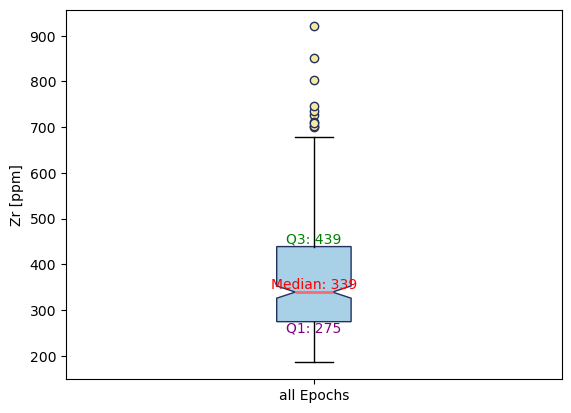

In [39]:
import pandas as pd
import matplotlib.pyplot as plt

my_dataset = pd.read_excel('Smith_glass_post_NYT_data.xlsx', sheet_name='Supp_traces')

# 🔥 hitung statistik penting
median = my_dataset['Zr'].median()
q1 = my_dataset['Zr'].quantile(0.25)
q3 = my_dataset['Zr'].quantile(0.75)

fig, ax = plt.subplots()

my_flierprops = dict(markerfacecolor='#f8e9a1', markeredgecolor='#24305e', marker='o')
my_medianprops = dict(color='#f76c6c', linewidth=2)
my_boxprops = dict(facecolor='#a8d0e6', edgecolor='#24305e')

ax.boxplot(my_dataset.Zr, patch_artist=True, notch=True,
           flierprops=my_flierprops, medianprops=my_medianprops, boxprops=my_boxprops)

# 🔥 tambahkan angka di grafik
ax.text(1, median, f'Median: {median:.0f}', ha='center', va='bottom', color='red')
ax.text(1, q1, f'Q1: {q1:.0f}', ha='center', va='top', color='purple')
ax.text(1, q3, f'Q3: {q3:.0f}', ha='center', va='bottom', color='green')

ax.set_ylabel('Zr [ppm]')
ax.set_xticks([1])
ax.set_xticklabels(['all Epochs'])

plt.show()

C:\Users\Naufal Nurhidayat\AppData\Local\Temp\ipykernel_15644\3245100315.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(x="Epoch", y="Zr", data=my_dataset, palette="Set3")


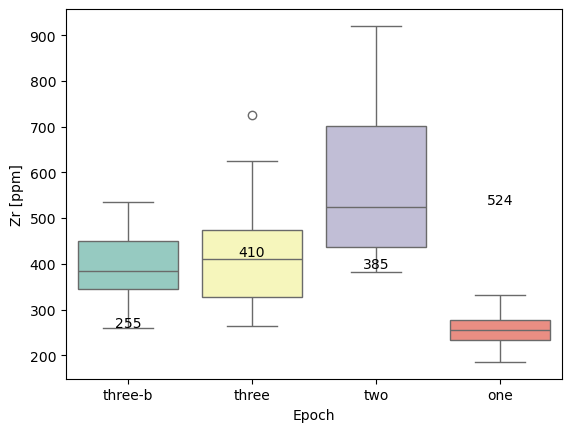

In [38]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

my_dataset = pd.read_excel('Smith_glass_post_NYT_data.xlsx', sheet_name='Supp_traces')

fig, ax = plt.subplots()

ax = sns.boxplot(x="Epoch", y="Zr", data=my_dataset, palette="Set3")

# 🔥 ambil median tiap kategori Epoch
medians = my_dataset.groupby("Epoch")["Zr"].median()

# 🔥 tampilkan angka median di tiap box
for i, epoch in enumerate(medians.index):
    ax.text(i, medians[epoch], f'{medians[epoch]:.0f}', 
            ha='center', va='bottom', color='black')

ax.set_xlabel('Epoch')
ax.set_ylabel('Zr [ppm]')

plt.show()